In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, brier_score_loss, roc_curve, auc,
                             average_precision_score)

In [59]:
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [60]:
df = pd.read_excel('/Users/MAC/PycharmProjects/диплом от 15.11/отфильтрованая таблица 19_04_26 с Killip.xlsx')


#формируем датафрейм с признаками (предикторами)
#непрерывные
cont_p_value_less_05 =[
'GRACE(Рассчет)',
'Систолическое АД(b)',
'Apache II',
'Диастолического АД(b)',
'Нейтрофилы (относительное значение)',
'Лейкоциты(a)',
'Нейтрофилы (абсолютное значение)',
'Нейтрофилы (абсолютное значение)(a)',
'Лимфоциты (относительное значение)',
'SpO2',
'Базофилы (относительное значение)',
'Эозинофилы (относительное значение)',
'Лейкоциты',
'СКФ',
'Возраст',
'eGFR',
'Эозинофилы (абсолютное значение)',
'ЧСС (b)',
'Глюкоза(a)',
'ФВ ЛЖ',
'СДЛА',
'Гематокрит(a)',
'Мочевина(b)',
'BLR (базофилы абс/лимфоциты абс)',
'Глюкоза в мг/дл',
'АЛАТ(a)',
'ELR (эозинофилы абс/лимфоциты абс',
'Лимфоциты (абсолютное значение)',
'МНО(a)',
'ПТИ(a)',
'ENR (эозин абс/нейтрофилы абс)',
'Hb(a)',
'Гематокрит',
'Эр(a)',
'Гемоглобин',
'Базофилы (абсолютное значение)',
'Эритроциты',
'АСАТ(a)',
'Креатинин(a)',
'Креатинин',
'Триглицериды(a)',
'Средний объем тромбоцита (MPV)',
'Вес',
'НПВ диаметр',
'Моноциты (относительное значение)',
'Продолжительность операции',
'КФК(a)',
'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)',
'RLR (RDW/ lymph abs)',
'Моноциты (абсолютное значение)',
'ЗСЛЖ',
'Рост',
'Распределение эритроцитов по объему (RDW-CV)',
'КСР ЛЖ',
'АПТВ(a)',
'PLR (тромбоциты/лимфоциты абс) (61-239)',
'La1',
'La2',
'Холестерин общий(a)',
'МЖП',


'Killip',
'killip',
'Класс ОСН по Killip']
#поменяла 14/03


#дихотомические
dih_p_value_less_05 =[
'GRACE (Высокий риск)',
'Отек легких',
'GRACE(Общее)>156',
'TIMI (Летальность) (Высокий риск)',
'GRACE(Общее)>140',
'Отек легких(b)',
'CADILLAC (Высокий риск)',
'интегрилин|эптифибатид|коромакс|агграстат',
'GRACE (Низкий риск)',
'РЕКОРД (Низкий риск)',
'РЕКОРД (Высокий риск)',
'Отек легких(a)',
'ФП b (после чкв)',
'А-В блокаДа',
'CADILLAC (Низкий риск)',
'PAMI (Высокий риск)',
'Интегреллин',
'Поражение ствола',
'GRACE (Средний риск)',
'Тирофибан',
'Инфаркт миокарда со стентированием в анамнезе',
'ФВ<30%',
'TIMI (Летальность) (Низкий риск)',
'Стенокардия в диагнозе при поступлении',
'ХОБЛ',
'Тромболизис',
'Общий анализ крови_экспресс раньше операции',
'СД',
'ФП a (в анамнезе)',
'ХБП',
'PAMI (Низкий риск)',
'ПИКС в диагнозе при поступлении',
'Левосимендан',
'Медицинская помощь оказана за первые 4 часа',
'PAMI (Средний риск)',
'Гипертоническая болезнь',
'TIMI категория',
] #поменяла 14/03

#категориальные признаки
cat_p_value_less_05 =[
'Количество пораженных сосудов(Syntax)',
'Количество пораженных сосудов(Значимость)',
'CADILLAC категория',
'РЕКОРД категория',
'PAMI категория',
'TIMI Летальность категория',
'Вид операции(ИБ)(Новый)',
'Исход заболевания',
'Инфаркт-зависимая артерия(Огригированная)',
'KDIGO',
'Baun',
'MKB категория',
'APACHE2 выписка категория',
'APACHE2 1сутки категория',
'APACHE2 3дня категория',
'ГБ стадия категория'
]
'''тут все проверила 14/03'''

all_predictors = cont_p_value_less_05 + dih_p_value_less_05 + cat_p_value_less_05 + ['КШ развился в реанимации']
predict_df = df[all_predictors]



y = predict_df['КШ развился в реанимации']
X = predict_df.drop('КШ развился в реанимации', axis=1)



#сразу закодируем признаки (категориальные)
for col in cat_p_value_less_05:
    if col in X.columns:
        # Преобразуем все значения в строки и заменяем NaN на специальную метку
        X[col] = X[col].astype(str)
#cоздаем ColumnTransformer
'''transformers = []
transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_p_value_less_05))'''


transformers = [
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_p_value_less_05)
    #('cont', StandardScaler(), cont_p_value_less_05)
]

preprocessor = ColumnTransformer(transformers=transformers, remainder='passthrough')

#применяем ColumnTransformer
X_encoded = preprocessor.fit_transform(X)

#cоздаем имена столбцов для закодированных категориальных признаков
encoded_feature_names_cat = preprocessor.transformers_[0][1].get_feature_names_out(cat_p_value_less_05)


#cоздаем DataFrame с закодированными признаками
#получаем индексы столбцов, которые не были закодированы
remainder_indices = [i for i, col in enumerate(X.columns) if col not in cat_p_value_less_05]

#получаем имена столбцов, которые не были закодированы
remainder_feature_names = [X.columns[i] for i in remainder_indices]

#объединяем названия всех столбцов
all_column_names = list(encoded_feature_names_cat) +remainder_feature_names
#cоздаем DataFrame с закодированными признаками
X_encoded_df = pd.DataFrame(X_encoded, columns=all_column_names)
X_y_encoded_df = pd.concat([X_encoded_df, y], axis=1)
X_y_encoded_df.to_excel('датафрейм с предикторами 19_04_26 с Killip.xlsx')

In [ ]:
#МЛР с killip

/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

Лучшая модель — итерация 45 с ROC-AUC на тесте = 0.8649
Коэффициенты лучшей модели: [[ 5.66131021e-05 -8.76560609e-03  4.95222808e-05 -1.68308756e-02
  -1.61919845e-02 -4.07693498e-04  2.93482725e-05 -2.24753875e-04
   2.53347845e-05 -6.29775551e-04  2.95789319e-04]]
Смещение (intercept): [-0.00016625]

РЕЗУЛЬТАТЫ МОДЕЛИ:
Кросс-валидационный ROC-AUC [95% ДИ] Тестовый ROC-AUC [95% ДИ]  Тестовый RAUC [95% ДИ] Тестовый Sensitivity [95% ДИ] Тестовый Specificity [95% ДИ] Тестовый F1-score [95% ДИ]   Тестовый PPV [95% ДИ]   Тестовый NPV [95% ДИ] Тестовый Brier Score [95% ДИ]
             0.7265 [0.7205; 0.7325]   0.7229 [0.7108; 0.7349] 0.1525 [0.1403; 0.1647]       0.6184 [0.5971; 0.6397]       0.7263 [0.7176; 0.7350]    0.1419 [0.1373; 0.1465] 0.0804 [0.0777; 0.0832] 0.9804 [0.9794; 0.9814]       0.0348 [0.0346; 0.0350]

SHAP АНАЛИЗ:


Estimating transforms: 100%|██████████| 1000/1000 [00:00<00:00, 6131.02it/s]


Класс ОСН по Killip: порог=3.00, min_shap=-0.0583, max_shap=0.1137
ЧСС (b): порог=30.00, min_shap=-0.6051, max_shap=0.3987
ХОБЛ: порог=1.00, min_shap=-0.0051, max_shap=0.0278
SpO2: порог=65.00, min_shap=-0.0989, max_shap=0.7584
Диастолического АД(b): порог=20.00, min_shap=-0.6657, max_shap=1.0092
Глюкоза(a): порог=14.08, min_shap=-0.0197, max_shap=0.0701
APACHE2 1сутки категория_Критический риск (25+): порог=1.00, min_shap=-0.0139, max_shap=0.1513
APACHE2 3дня категория_Низкий риск (0-10): порог=0.00, min_shap=-0.0103, max_shap=0.0910
Apache II: порог=36.00, min_shap=-0.0619, max_shap=0.4354
Лейкоциты(a): порог=18.97, min_shap=-0.1660, max_shap=0.4670
SII (тромбоциты*нейтрофилы абс / лимфоциты абс): порог=7353.06, min_shap=-0.7253, max_shap=4.7958


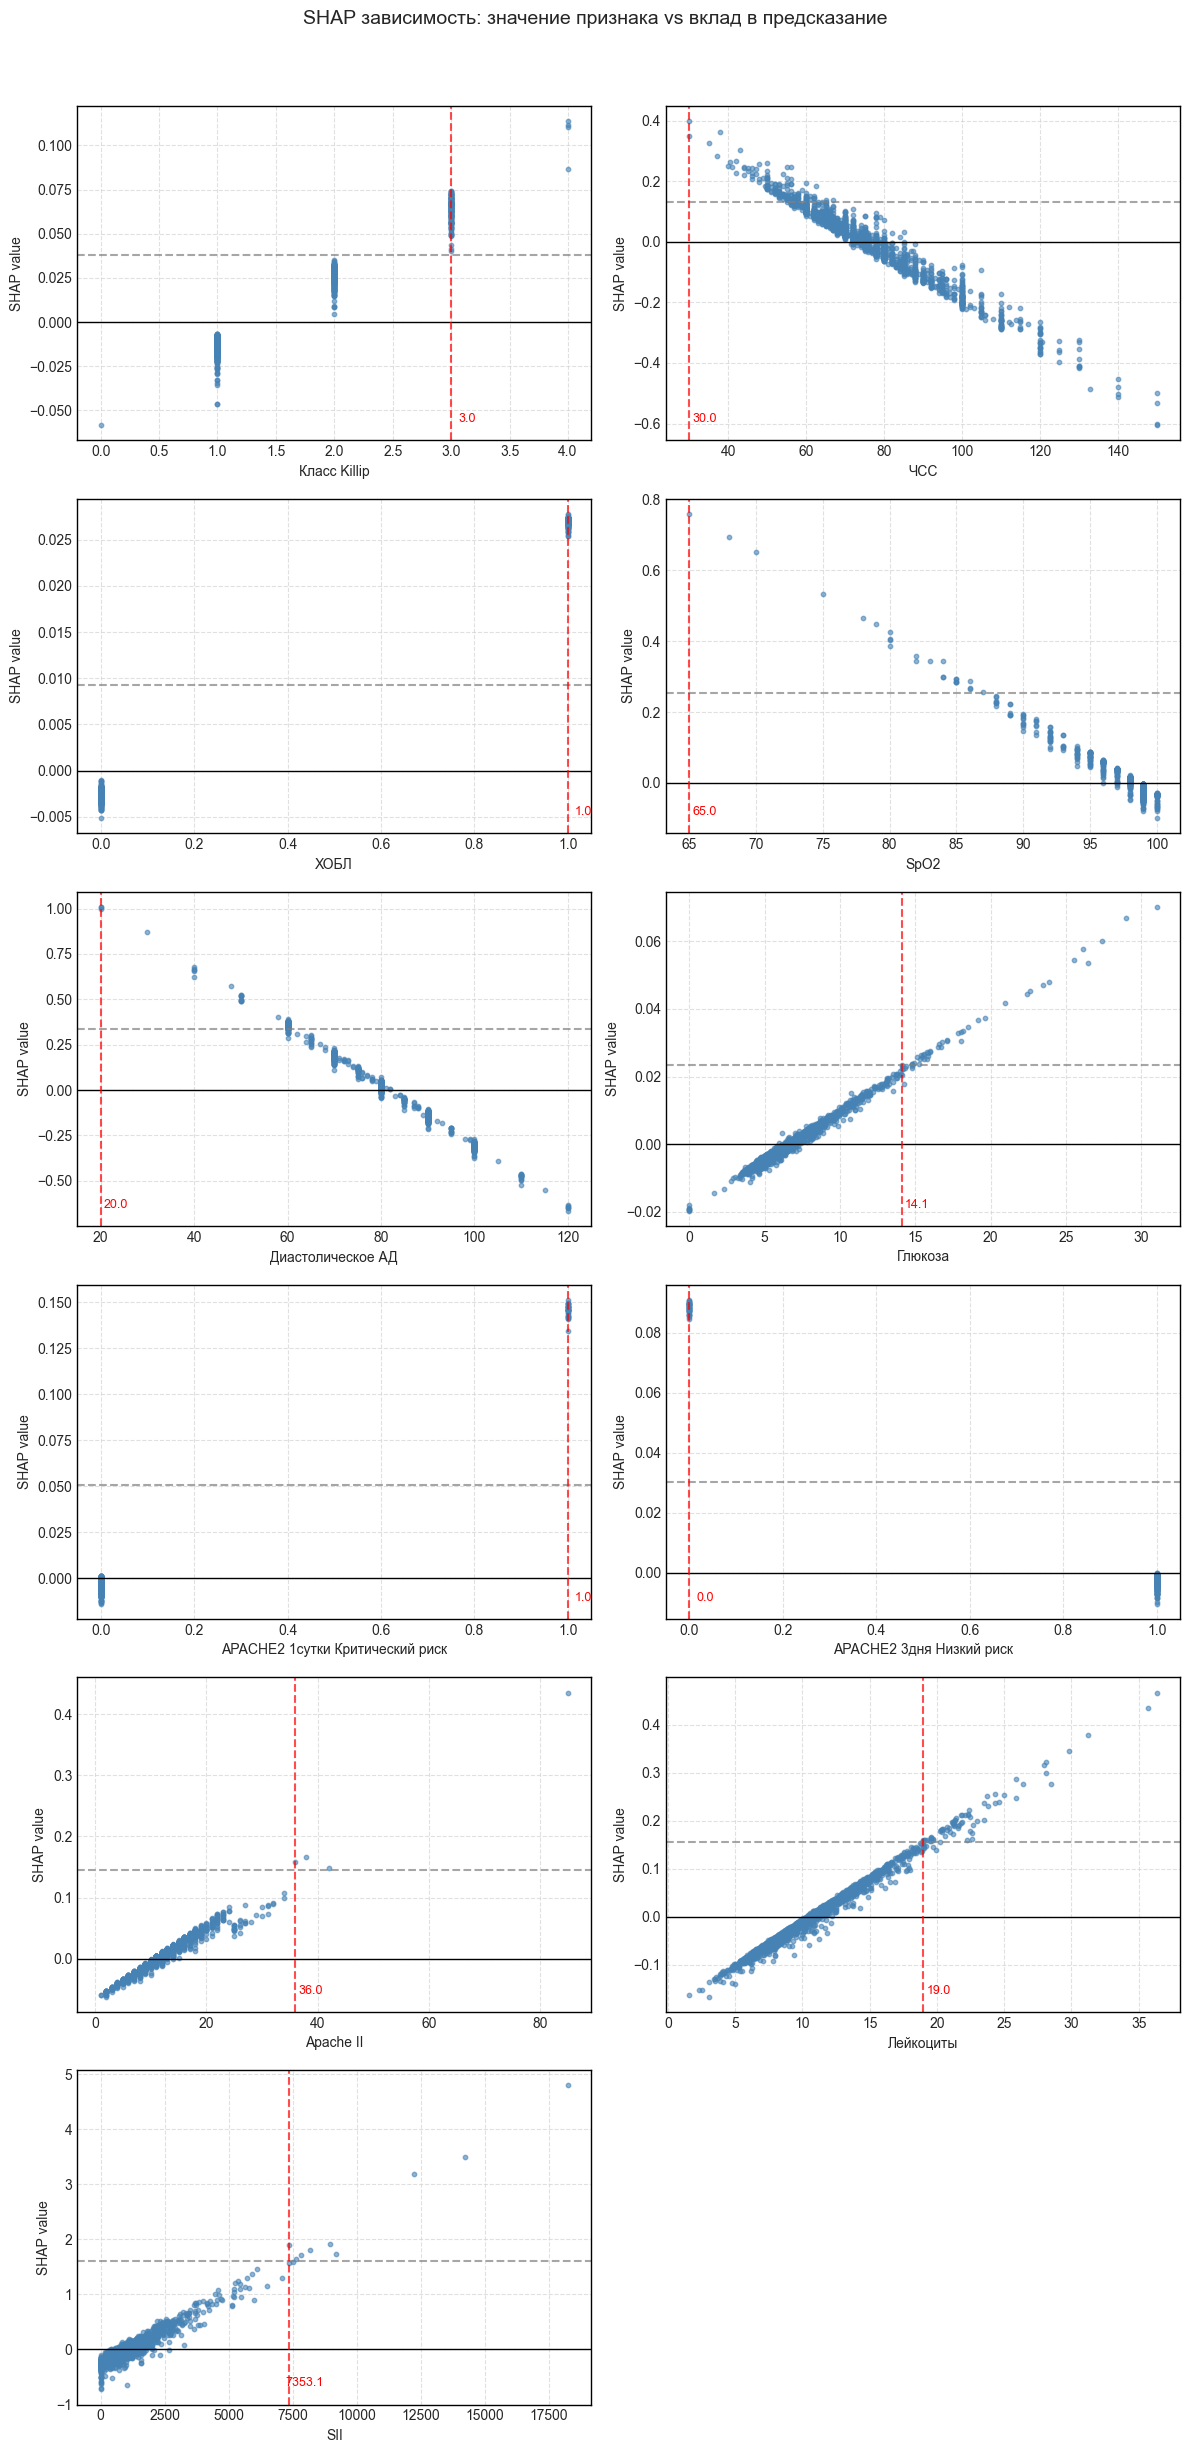


Создание summary plot...


/var/folders/rb/hpt9sf5d50d2jty9t6ydq7ww0000gn/T/ipykernel_49557/1344200254.py:244: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, show=False)


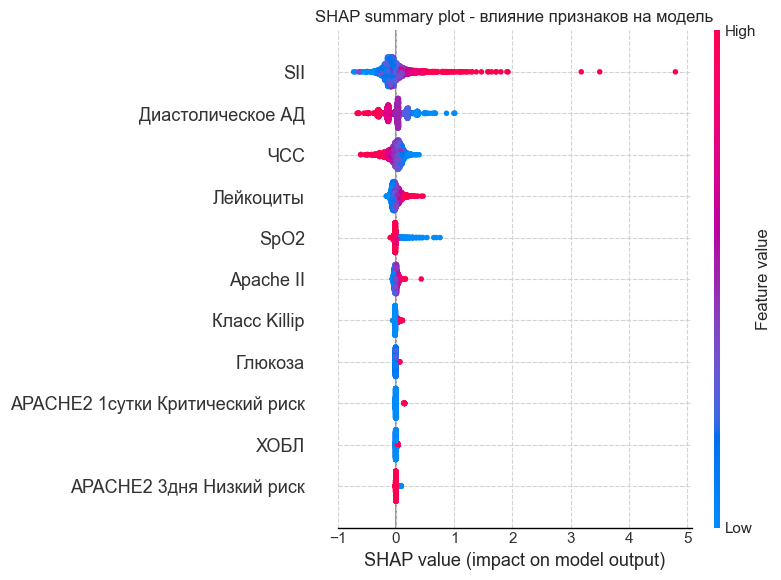


Создание bar plot...


/var/folders/rb/hpt9sf5d50d2jty9t6ydq7ww0000gn/T/ipykernel_49557/1344200254.py:252: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, plot_type="bar", show=False)


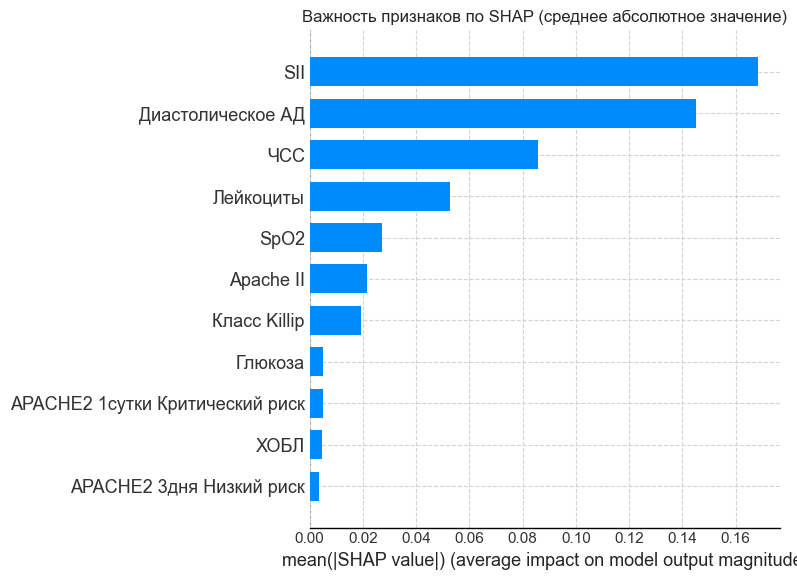


Создание waterfall plot для первого пациента...


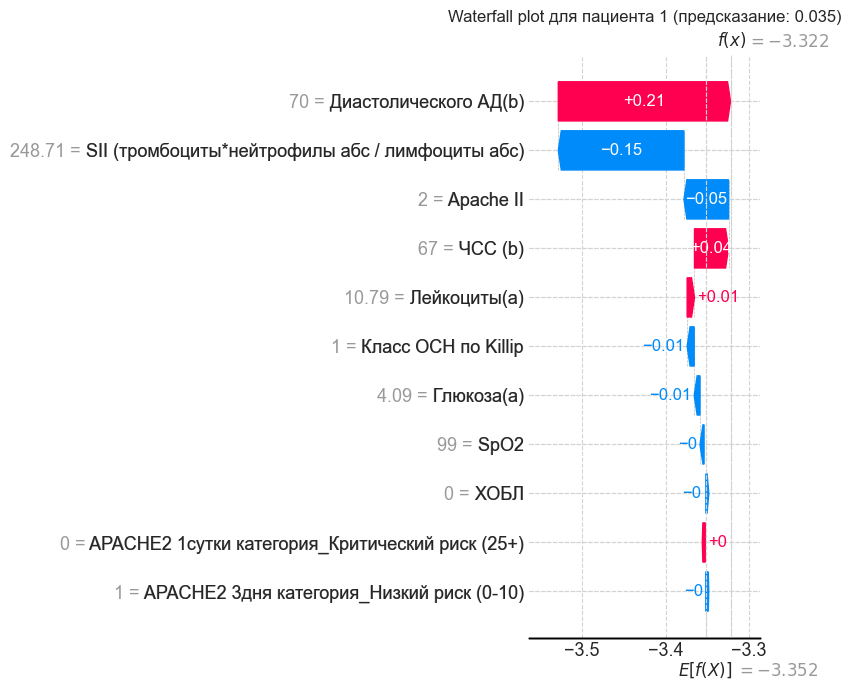


SHAP значения сохранены в 'shap_values.xlsx'

Создание дополнительных графиков зависимости...


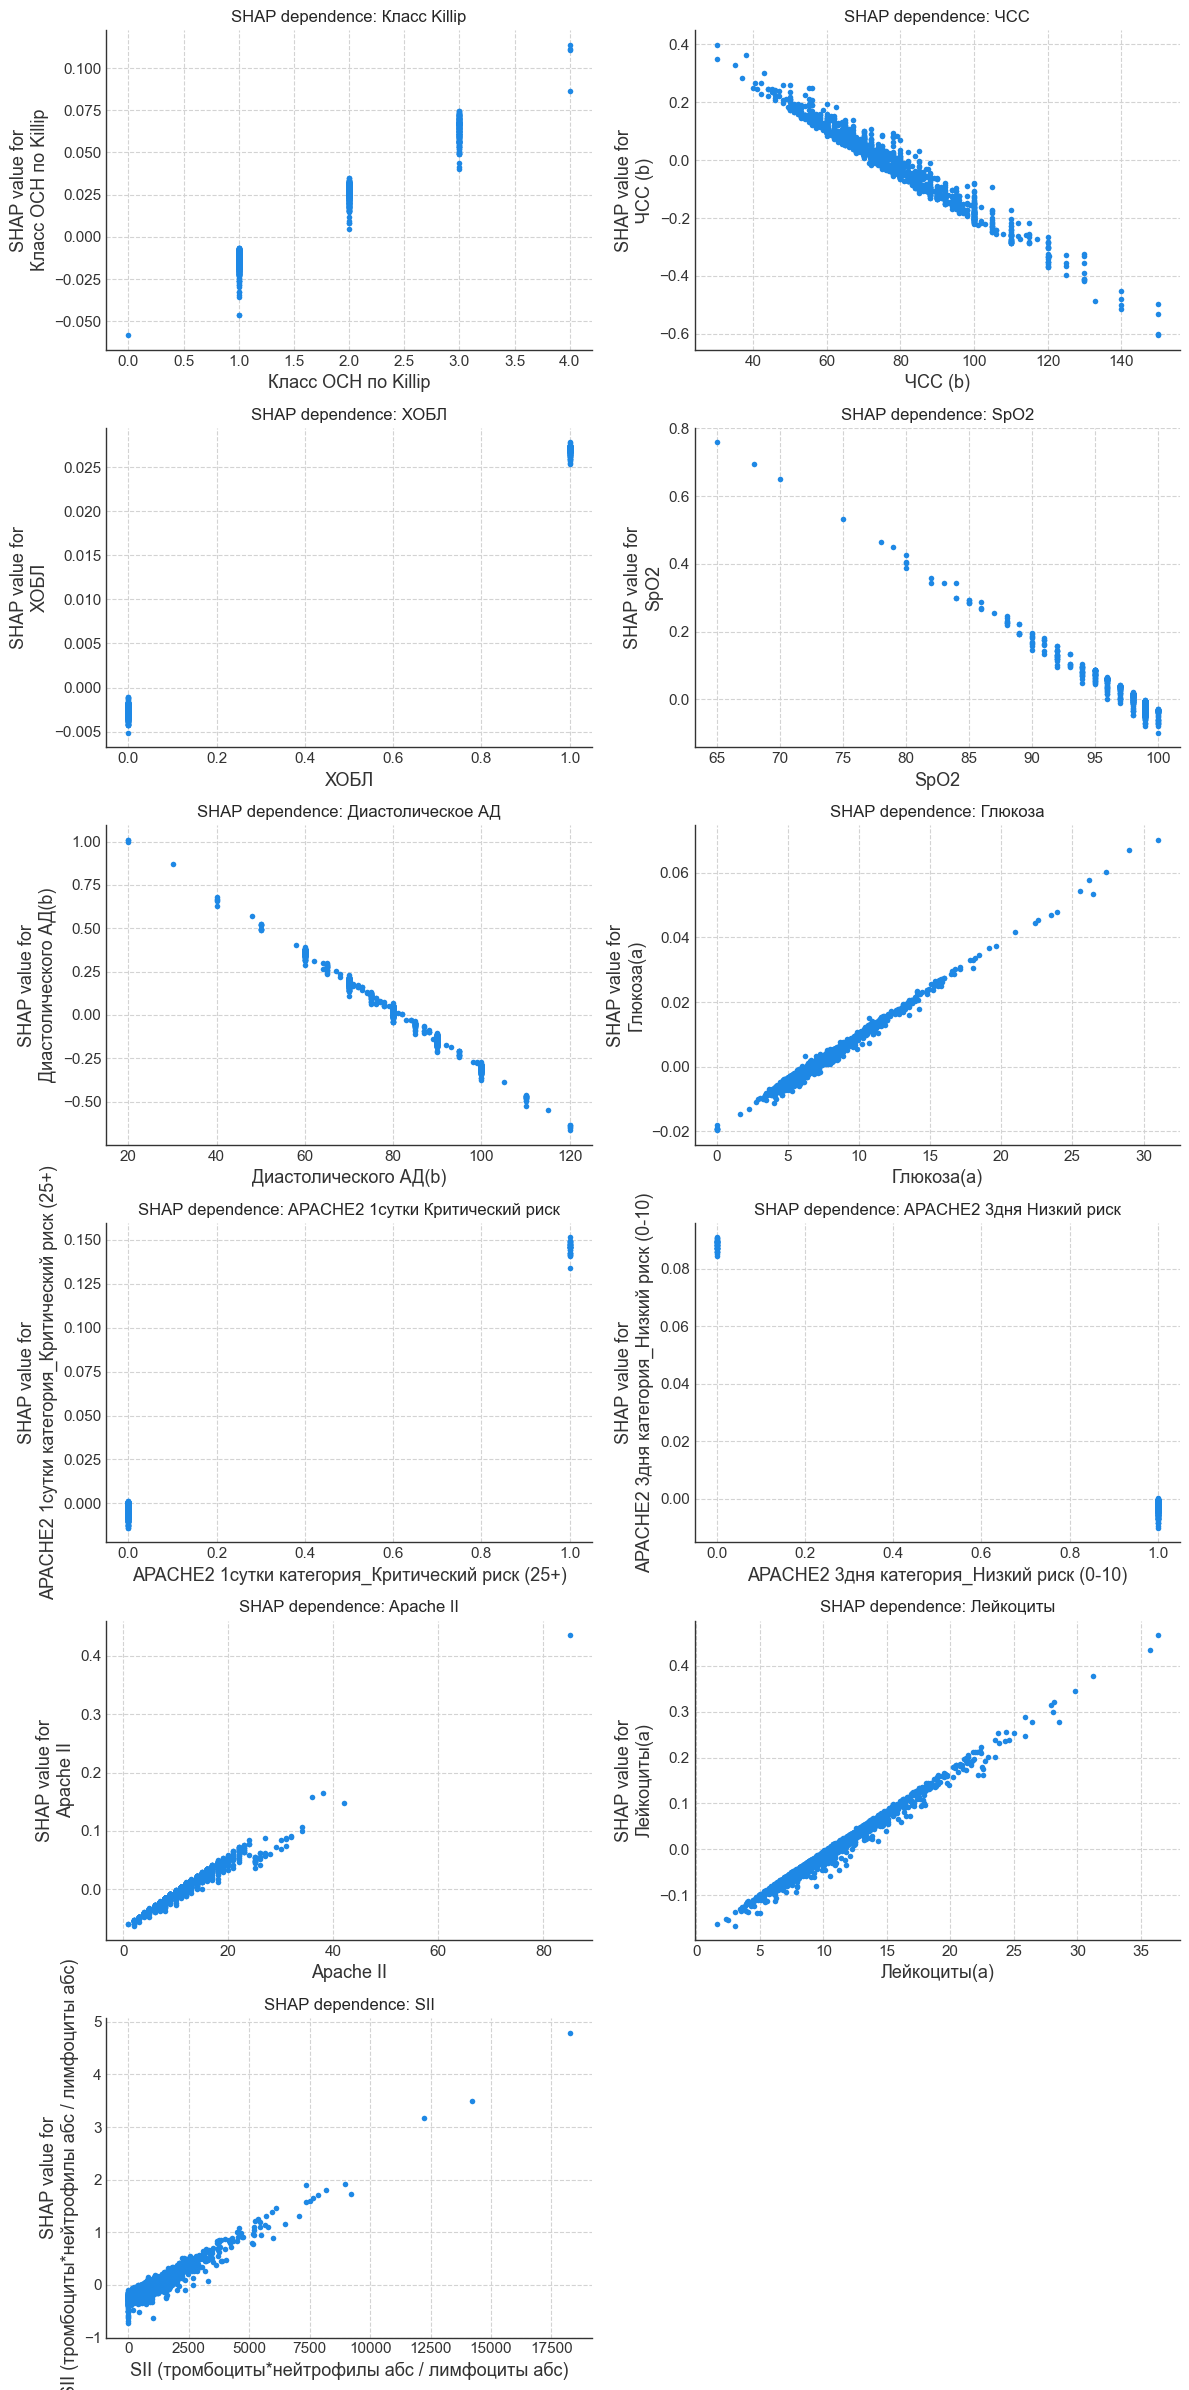


SHAP анализ завершен!


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, average_precision_score, recall_score, confusion_matrix, precision_score, f1_score, brier_score_loss
from scipy import stats
import shap

# ==================== ЗАГРУЗКА ДАННЫХ ====================
predict_df = pd.read_excel('датафрейм с предикторами 19_04_26 с Killip.xlsx')

# ==================== ФУНКЦИИ ДЛЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ ====================
def compute_confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    interval = sem * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean, mean - interval, mean + interval

def format_confidence_interval(mean, lower, upper):
    return f"{mean:.4f} [{lower:.4f}; {upper:.4f}]"

# ==================== ПРИЗНАКИ ====================
features = [
    'Класс ОСН по Killip',
    'ЧСС (b)',
    'ХОБЛ',
    'SpO2',
    'Диастолического АД(b)',
    'Глюкоза(a)',
    'APACHE2 1сутки категория_Критический риск (25+)',
    'APACHE2 3дня категория_Низкий риск (0-10)',
    'Apache II',
    'Лейкоциты(a)',
    'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)'
]

# Очистка данных
predict_df_clean = predict_df.dropna(subset=features)

# Подготовка данных
X = predict_df_clean[features]
y = predict_df_clean['КШ развился в реанимации']

# ==================== ОБУЧЕНИЕ МОДЕЛИ ====================
results_data = []
n_repeats = 100
n_splits = 5
all_roc_auc_cv = []
all_roc_auc_test = []
all_pr_auc_test = []
all_sensitivity_test = []
all_specificity_test = []
all_f1_test = []
all_ppv_test = []
all_npv_test = []
all_brier_test = []

models = []

for i in range(n_repeats):
    np.random.seed(i + 42)
    # Разделение на обучающую и тестовую выборки (80/20)
    x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=i + 42)

    model = LogisticRegression(C = 0.1, max_iter=1000, penalty='l2', solver ='saga')

    # Кросс-валидация на 80% выборке
    cv_results = cross_validate(model, x_train, y_train, cv=StratifiedKFold(n_splits=n_splits),
                                scoring='roc_auc', return_estimator=True)
    all_roc_auc_cv.extend(cv_results['test_score'])

    # Обучение модели на всей обучающей выборке
    model.fit(x_train, y_train)

    # Получаем вероятности для тренировочной выборки, чтобы найти порог
    y_train_prob = model.predict_proba(x_train)[:, 1]
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
    optimal_idx = np.argmax(tpr_train - fpr_train)
    best_threshold = thresholds_train[optimal_idx]

    # Получаем вероятности для тестовой выборки
    y_test_prob = model.predict_proba(x_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    # Метрики
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    all_roc_auc_test.append(auc(fpr, tpr))
    all_pr_auc_test.append(average_precision_score(y_test, y_test_prob))
    all_sensitivity_test.append(recall_score(y_test, y_test_pred))

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    all_specificity_test.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    all_npv_test.append(tn / (tn + fn) if (tn + fn) > 0 else 0)
    all_ppv_test.append(precision_score(y_test, y_test_pred, zero_division=0))
    all_f1_test.append(f1_score(y_test, y_test_pred, zero_division=0))
    all_brier_test.append(brier_score_loss(y_test, y_test_prob))

    models.append(model)

# Находим лучшую модель
best_idx = all_roc_auc_test.index(max(all_roc_auc_test))
best_model = models[best_idx]

print(f"Лучшая модель — итерация {best_idx + 1} с ROC-AUC на тесте = {all_roc_auc_test[best_idx]:.4f}")
print("Коэффициенты лучшей модели:", best_model.coef_)
print("Смещение (intercept):", best_model.intercept_)

# ==================== ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ====================
roc_auc_cv_mean, roc_auc_cv_lower, roc_auc_cv_upper = compute_confidence_interval(all_roc_auc_cv)
roc_auc_test_mean, roc_auc_test_lower, roc_auc_test_upper = compute_confidence_interval(all_roc_auc_test)
pr_auc_test_mean, pr_auc_test_lower, pr_auc_test_upper = compute_confidence_interval(all_pr_auc_test)
sensitivity_test_mean, sensitivity_test_lower, sensitivity_test_upper = compute_confidence_interval(all_sensitivity_test)
specificity_test_mean, specificity_test_lower, specificity_test_upper = compute_confidence_interval(all_specificity_test)
f1_test_mean, f1_test_lower, f1_test_upper = compute_confidence_interval(all_f1_test)
ppv_test_mean, ppv_test_lower, ppv_test_upper = compute_confidence_interval(all_ppv_test)
npv_test_mean, npv_test_lower, npv_test_upper = compute_confidence_interval(all_npv_test)
brier_test_mean, brier_test_lower, brier_test_upper = compute_confidence_interval(all_brier_test)

results_data.append({
    'Кросс-валидационный ROC-AUC [95% ДИ]': format_confidence_interval(roc_auc_cv_mean, roc_auc_cv_lower, roc_auc_cv_upper),
    'Тестовый ROC-AUC [95% ДИ]': format_confidence_interval(roc_auc_test_mean, roc_auc_test_lower, roc_auc_test_upper),
    'Тестовый RAUC [95% ДИ]': format_confidence_interval(pr_auc_test_mean, pr_auc_test_lower, pr_auc_test_upper),
    'Тестовый Sensitivity [95% ДИ]': format_confidence_interval(sensitivity_test_mean, sensitivity_test_lower, sensitivity_test_upper),
    'Тестовый Specificity [95% ДИ]': format_confidence_interval(specificity_test_mean, specificity_test_lower, specificity_test_upper),
    'Тестовый F1-score [95% ДИ]': format_confidence_interval(f1_test_mean, f1_test_lower, f1_test_upper),
    'Тестовый PPV [95% ДИ]': format_confidence_interval(ppv_test_mean, ppv_test_lower, ppv_test_upper),
    'Тестовый NPV [95% ДИ]': format_confidence_interval(npv_test_mean, npv_test_lower, npv_test_upper),
    'Тестовый Brier Score [95% ДИ]': format_confidence_interval(brier_test_mean, brier_test_lower, brier_test_upper),
})

results_df = pd.DataFrame(results_data)
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛИ:")
print("="*80)
print(results_df.to_string(index=False))

# ==================== ПОЛУЧАЕМ ДАННЫЕ ДЛЯ ЛУЧШЕЙ МОДЕЛИ ====================
np.random.seed(best_idx + 42)
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=best_idx + 42
)

# ==================== SHAP АНАЛИЗ ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ ====================
print("\n" + "="*80)
print("SHAP АНАЛИЗ:")
print("="*80)

# Создаем explainer для линейной модели
# Используем LinearExplainer для логистической регрессии
explainer = shap.LinearExplainer(best_model, X_train_best, feature_perturbation='correlation_dependent')

# Рассчитываем SHAP значения
shap_values = explainer.shap_values(X_train_best)

# Для бинарной классификации shap_values может быть списком из двух массивов
# Нам нужны значения для класса 1 (положительный исход)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Создаем DataFrame с SHAP значениями
shap_values_df = pd.DataFrame(shap_values, columns=features)

# Настройка графиков
plt.rcParams.update({'font.size': 10})
k = 3
features_ru = {
    'Класс ОСН по Killip': 'Класс Killip',
    'ЧСС (b)': 'ЧСС',
    'ХОБЛ': 'ХОБЛ',
    'SpO2': 'SpO2',
    'Диастолического АД(b)': 'Диастолическое АД',
    'Глюкоза(a)' : 'Глюкоза',
    'APACHE2 1сутки категория_Критический риск (25+)': 'APACHE2 1сутки Критический риск',
    'APACHE2 3дня категория_Низкий риск (0-10)': 'APACHE2 3дня Низкий риск',
    'Apache II' : 'Apache II',
    'Лейкоциты(a)': 'Лейкоциты',
    'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)': 'SII'
}



# Создаем графики для всех признаков
n_features = len(features)
n_rows = (n_features + 1) // 2

plt.figure(figsize=[12, 4 * n_rows], dpi=100)

for idx, feature in enumerate(features):
    plt.subplot(n_rows, 2, idx + 1)

    # Создаем DataFrame для текущего признака
    pp = pd.DataFrame({
        'X': np.array(X_train_best[feature]),
        'shap': np.array(shap_values[:, idx])
    })

    # Находим пороговое значение SHAP
    m = np.max(pp['shap'])
    # Значение предиктора, с которого SHAP превышает max(shap)/k
    mask = pp['shap'] > m/k
    if mask.any():
        xx = pp.loc[mask, 'X'].min()
    else:
        xx = np.nan
    yy = np.min(pp['shap'])

    port_text = f"{xx:.2f}" if not np.isnan(xx) else "не найден"
    print(f"{feature}: порог={port_text}, min_shap={yy:.4f}, max_shap={m:.4f}")

    plt.minorticks_on()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.scatter(X_train_best[feature], shap_values[:, idx], s=10, alpha=0.6, c='steelblue')

    # Настройка границ осей
    x_min = np.min(X_train_best[feature])
    x_max = np.max(X_train_best[feature])
    x_range = x_max - x_min
    plt.xlim(x_min - x_range/20, x_max + x_range/20)

    # Подписи
    feature_name_ru = features_ru.get(feature, feature)
    plt.xlabel(feature_name_ru)
    plt.ylabel('SHAP value')

    # Добавляем линии
    plt.axhline(y=0, color='black', linewidth=1)
    plt.axhline(y=m/k, color='gray', linestyle='--', alpha=0.7)

    if not np.isnan(xx):
        plt.axvline(x=xx, color='red', linestyle='--', alpha=0.7)
        plt.text(xx + x_range/30, yy, f'{xx:.1f}',
                 color='red', ha='center', va='bottom', fontsize=9)

plt.suptitle('SHAP зависимость: значение признака vs вклад в предсказание', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==================== ДОПОЛНИТЕЛЬНЫЕ SHAP ВИЗУАЛИЗАЦИИ ====================
feature_names_ru = [features_ru[feature] for feature in features]
# 1. Summary plot (главный график важности признаков)
print("\nСоздание summary plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, show=False)
plt.title('SHAP summary plot - влияние признаков на модель', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Bar plot (средние абсолютные SHAP значения)
print("\nСоздание bar plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, plot_type="bar", show=False)
plt.title('Важность признаков по SHAP (среднее абсолютное значение)', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Waterfall plot для конкретного наблюдения (например, первого пациента)
print("\nСоздание waterfall plot для первого пациента...")
# Получаем expected value
if isinstance(explainer.expected_value, list):
    expected_value = explainer.expected_value[1]
else:
    expected_value = explainer.expected_value

# Создаем Explanation object
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=expected_value,
    data=X_train_best.iloc[0].values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False, max_display=len(features))
plt.title(f'Waterfall plot для пациента 1 (предсказание: {best_model.predict_proba(X_train_best.iloc[0:1])[0,1]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Сохраняем SHAP значения для дальнейшего анализа
shap_df = pd.DataFrame(shap_values, columns=[f'SHAP_{f}' for f in features])
shap_df.to_excel('shap_values.xlsx', index=False)
print("\nSHAP значения сохранены в 'shap_values.xlsx'")

# 5. Дополнительно: график зависимости SHAP от значения признака (альтернативный вариант)
print("\nСоздание дополнительных графиков зависимости...")
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    shap.dependence_plot(
        feature, shap_values, X_train_best,
        feature_names=features, ax=ax, show=False,
        interaction_index=None
    )
    ax.set_title(f'SHAP dependence: {features_ru.get(feature, feature)}')

# Скрываем лишние подграфики
for idx in range(len(features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SHAP анализ завершен!")
print("="*80)

In [ ]:
#МЛР контрольная

/Users/MAC/PycharmProjects/диплом от 15.11/.venv/lib/python3.12/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Лучшая модель — итерация 49 с ROC-AUC на тесте = 0.9430
Коэффициенты лучшей модели: [[ 0.0074172   0.05354531 -0.03154787  0.0009643  -0.00342146  0.07432903
   0.45997054 -0.17080951  0.00369702 -0.01508027  0.03372784 -0.03657691
   0.00190915 -0.11238553 -0.54554178]]
Смещение (intercept): [-0.02935682]

РЕЗУЛЬТАТЫ МОДЕЛИ:
Кросс-валидационный ROC-AUC [95% ДИ] Тестовый ROC-AUC [95% ДИ]  Тестовый RAUC [95% ДИ] Тестовый Sensitivity [95% ДИ] Тестовый Specificity [95% ДИ] Тестовый F1-score [95% ДИ]   Тестовый PPV [95% ДИ]   Тестовый NPV [95% ДИ] Тестовый Brier Score [95% ДИ]
             0.8220 [0.8160; 0.8280]   0.8310 [0.8197; 0.8422] 0.2273 [0.2122; 0.2425]       0.6908 [0.6629; 0.7186]       0.8205 [0.8099; 0.8311]    0.1993 [0.1910; 0.2077] 0.1178 [0.1123; 0.1234] 0.9879 [0.9868; 0.9889]       0.0296 [0.0290; 0.0301]

SHAP АНАЛИЗ:


Estimating transforms: 100%|██████████| 1000/1000 [00:00<00:00, 4315.54it/s]


GRACE(Рассчет): порог=141.00, min_shap=-1.0460, max_shap=1.1472
Средний объем тромбоцита (MPV): порог=10.90, min_shap=-0.1933, max_shap=0.2803
SpO2: порог=60.00, min_shap=-0.1735, max_shap=2.1812
Нейтрофилы (относительное значение): порог=66.60, min_shap=-0.7113, max_shap=0.3652
ФВ ЛЖ: порог=18.00, min_shap=-0.2763, max_shap=0.4217
Apache II: порог=19.00, min_shap=-0.8791, max_shap=2.5283
ХОБЛ: порог=1.00, min_shap=-0.1343, max_shap=0.5105
Лимфоциты (абсолютное значение): порог=0.39, min_shap=-1.3066, max_shap=0.3879
Глюкоза в мг/дл: порог=243.63, min_shap=-0.4366, max_shap=1.8690
Базофилы (абсолютное значение): порог=0.00, min_shap=-0.4861, max_shap=0.0659
Лейкоциты(a): порог=17.30, min_shap=-0.3764, max_shap=1.0701
Диастолического АД(b): порог=20.00, min_shap=-1.5791, max_shap=2.3901
PLR (тромбоциты/лимфоциты абс) (61-239): порог=466.67, min_shap=-0.4484, max_shap=2.4371
TIMI категория: порог=0.00, min_shap=-0.0376, max_shap=0.1596
APACHE2 3дня категория_Низкий риск (0-10): порог=0.0

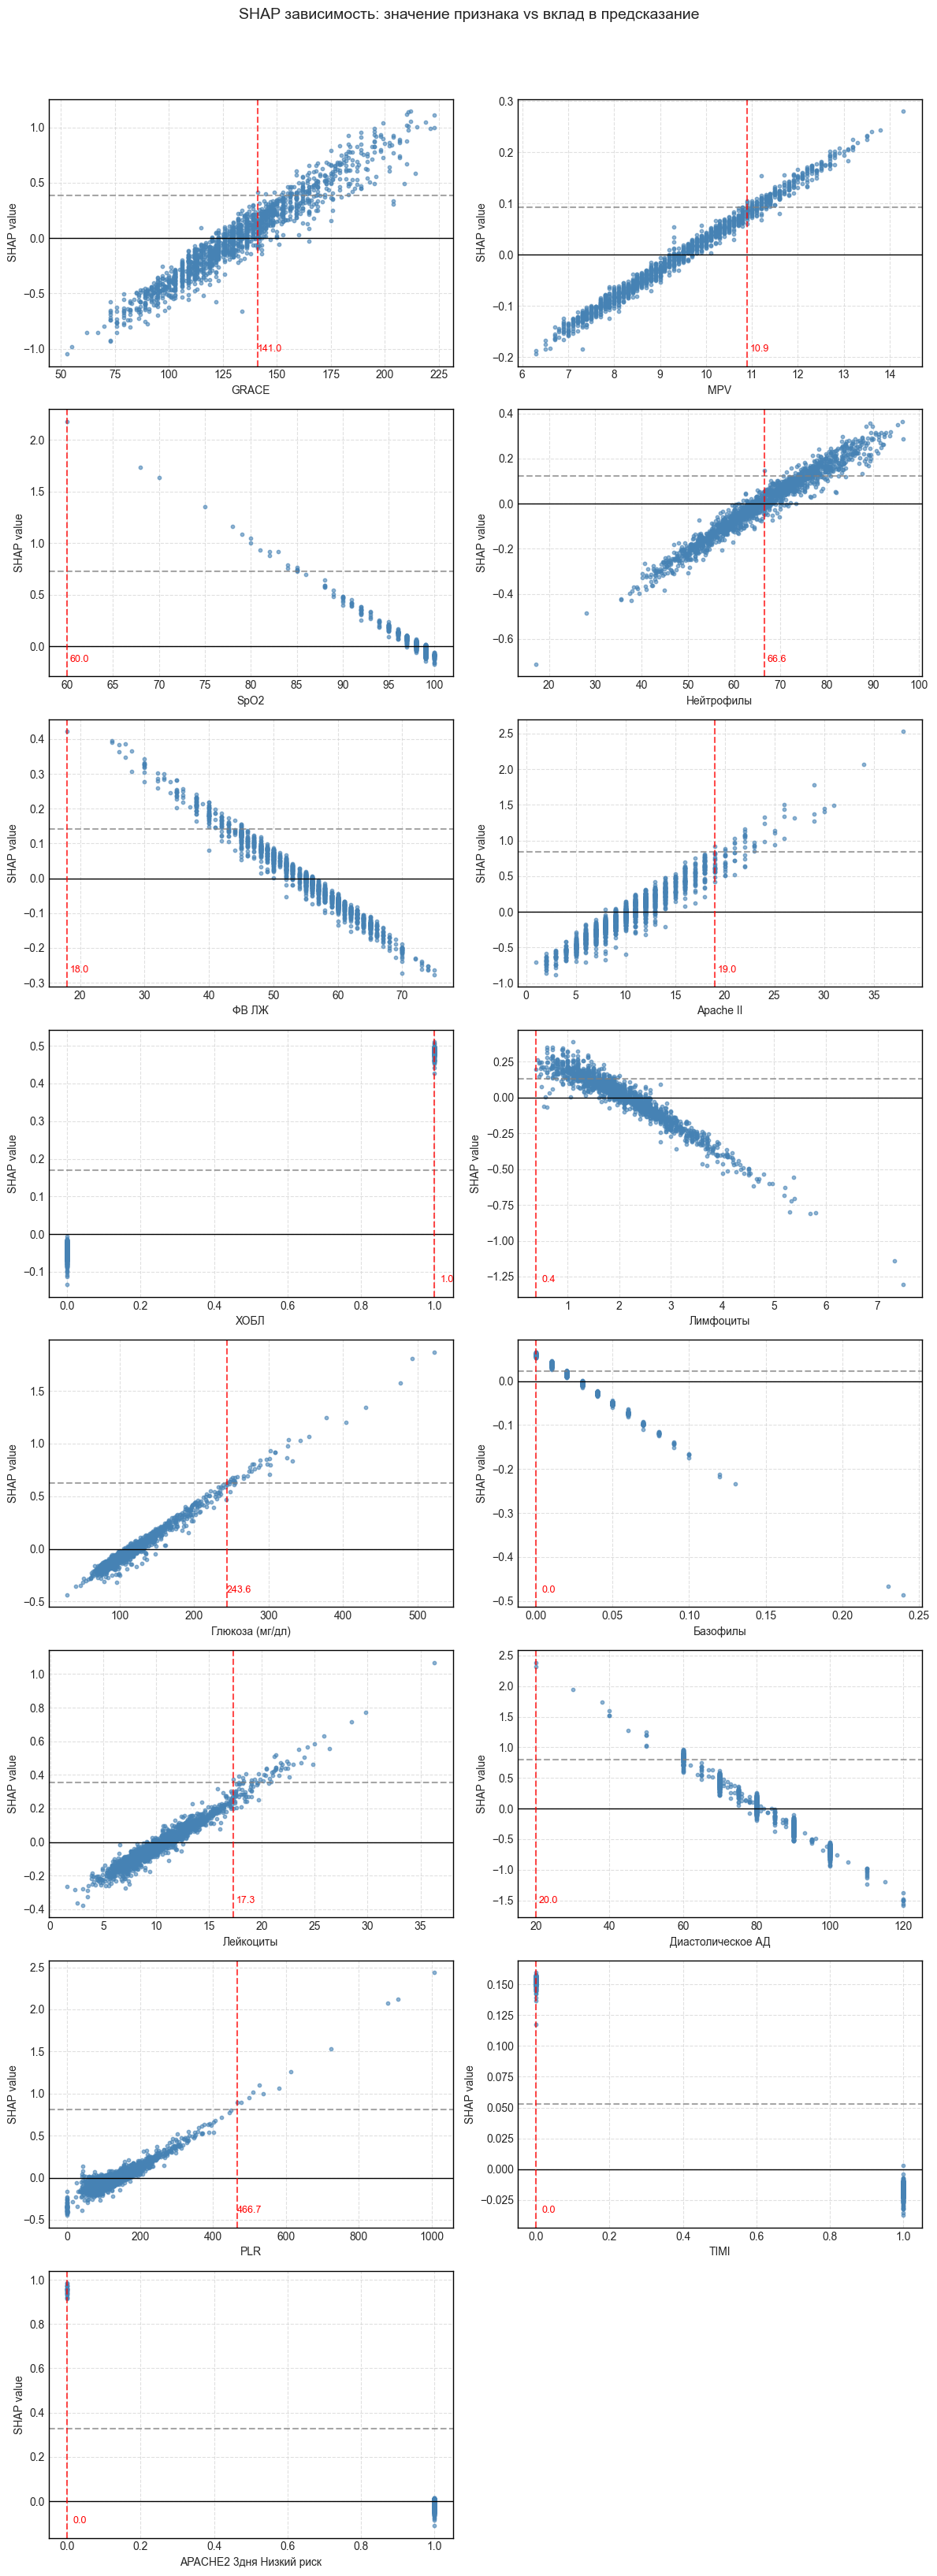


Создание summary plot...


/var/folders/rb/hpt9sf5d50d2jty9t6ydq7ww0000gn/T/ipykernel_49557/2775198996.py:248: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, show=False)


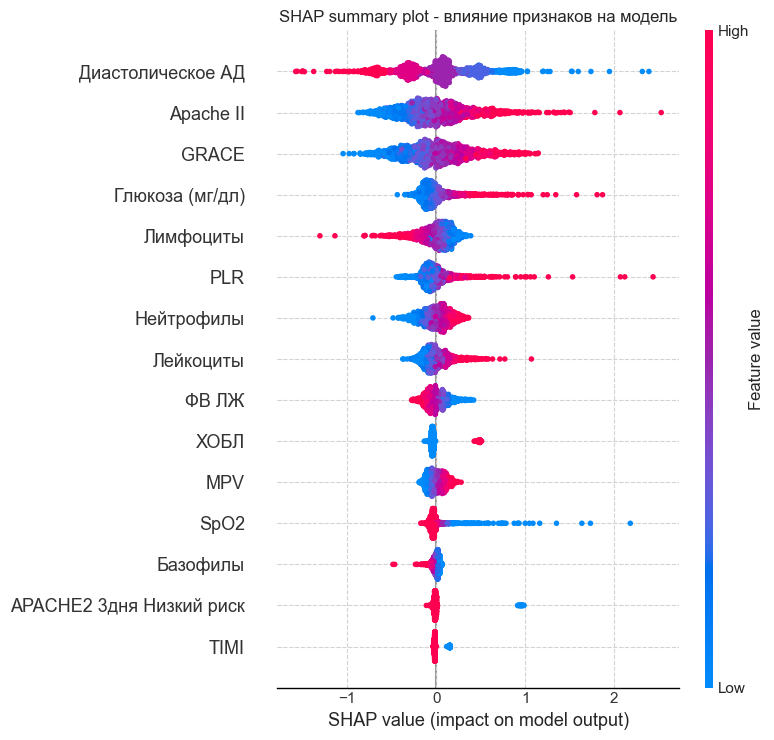


Создание bar plot...


/var/folders/rb/hpt9sf5d50d2jty9t6ydq7ww0000gn/T/ipykernel_49557/2775198996.py:256: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, plot_type="bar", show=False)


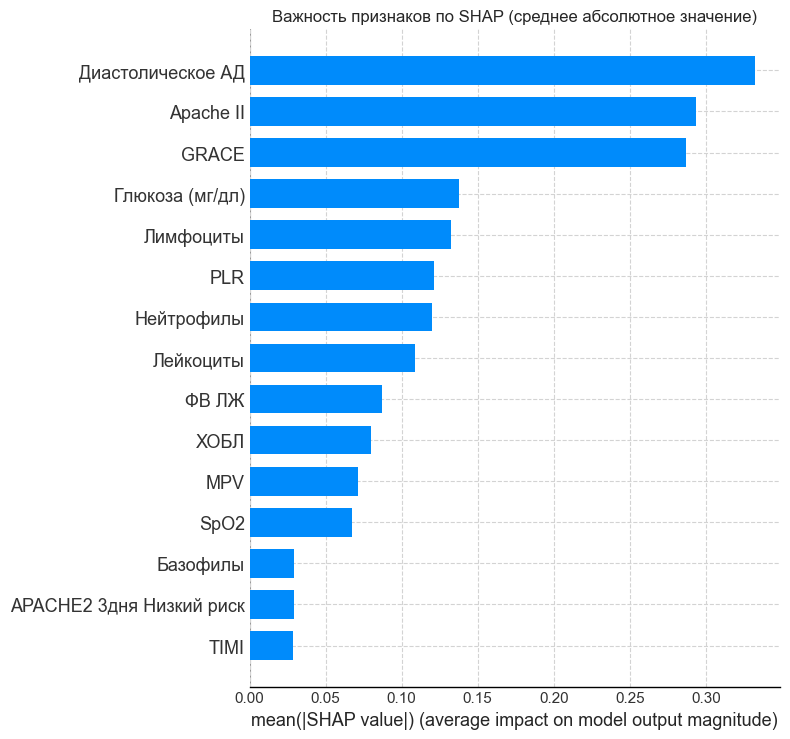


Создание waterfall plot для первого пациента...


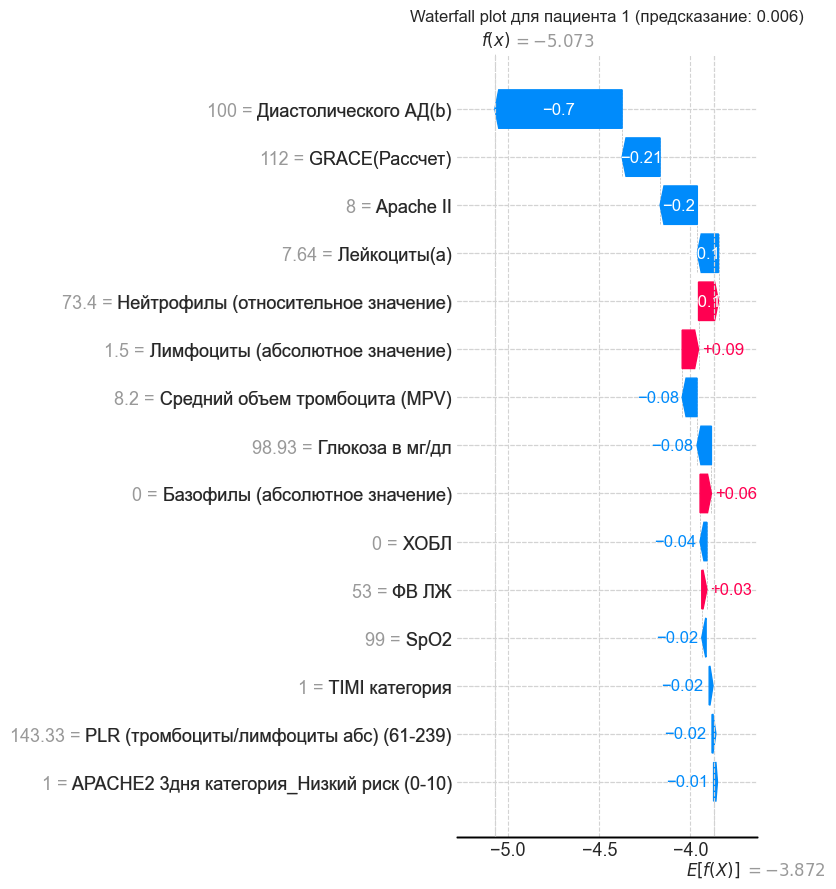


SHAP значения сохранены в 'shap_values.xlsx'

Создание дополнительных графиков зависимости...


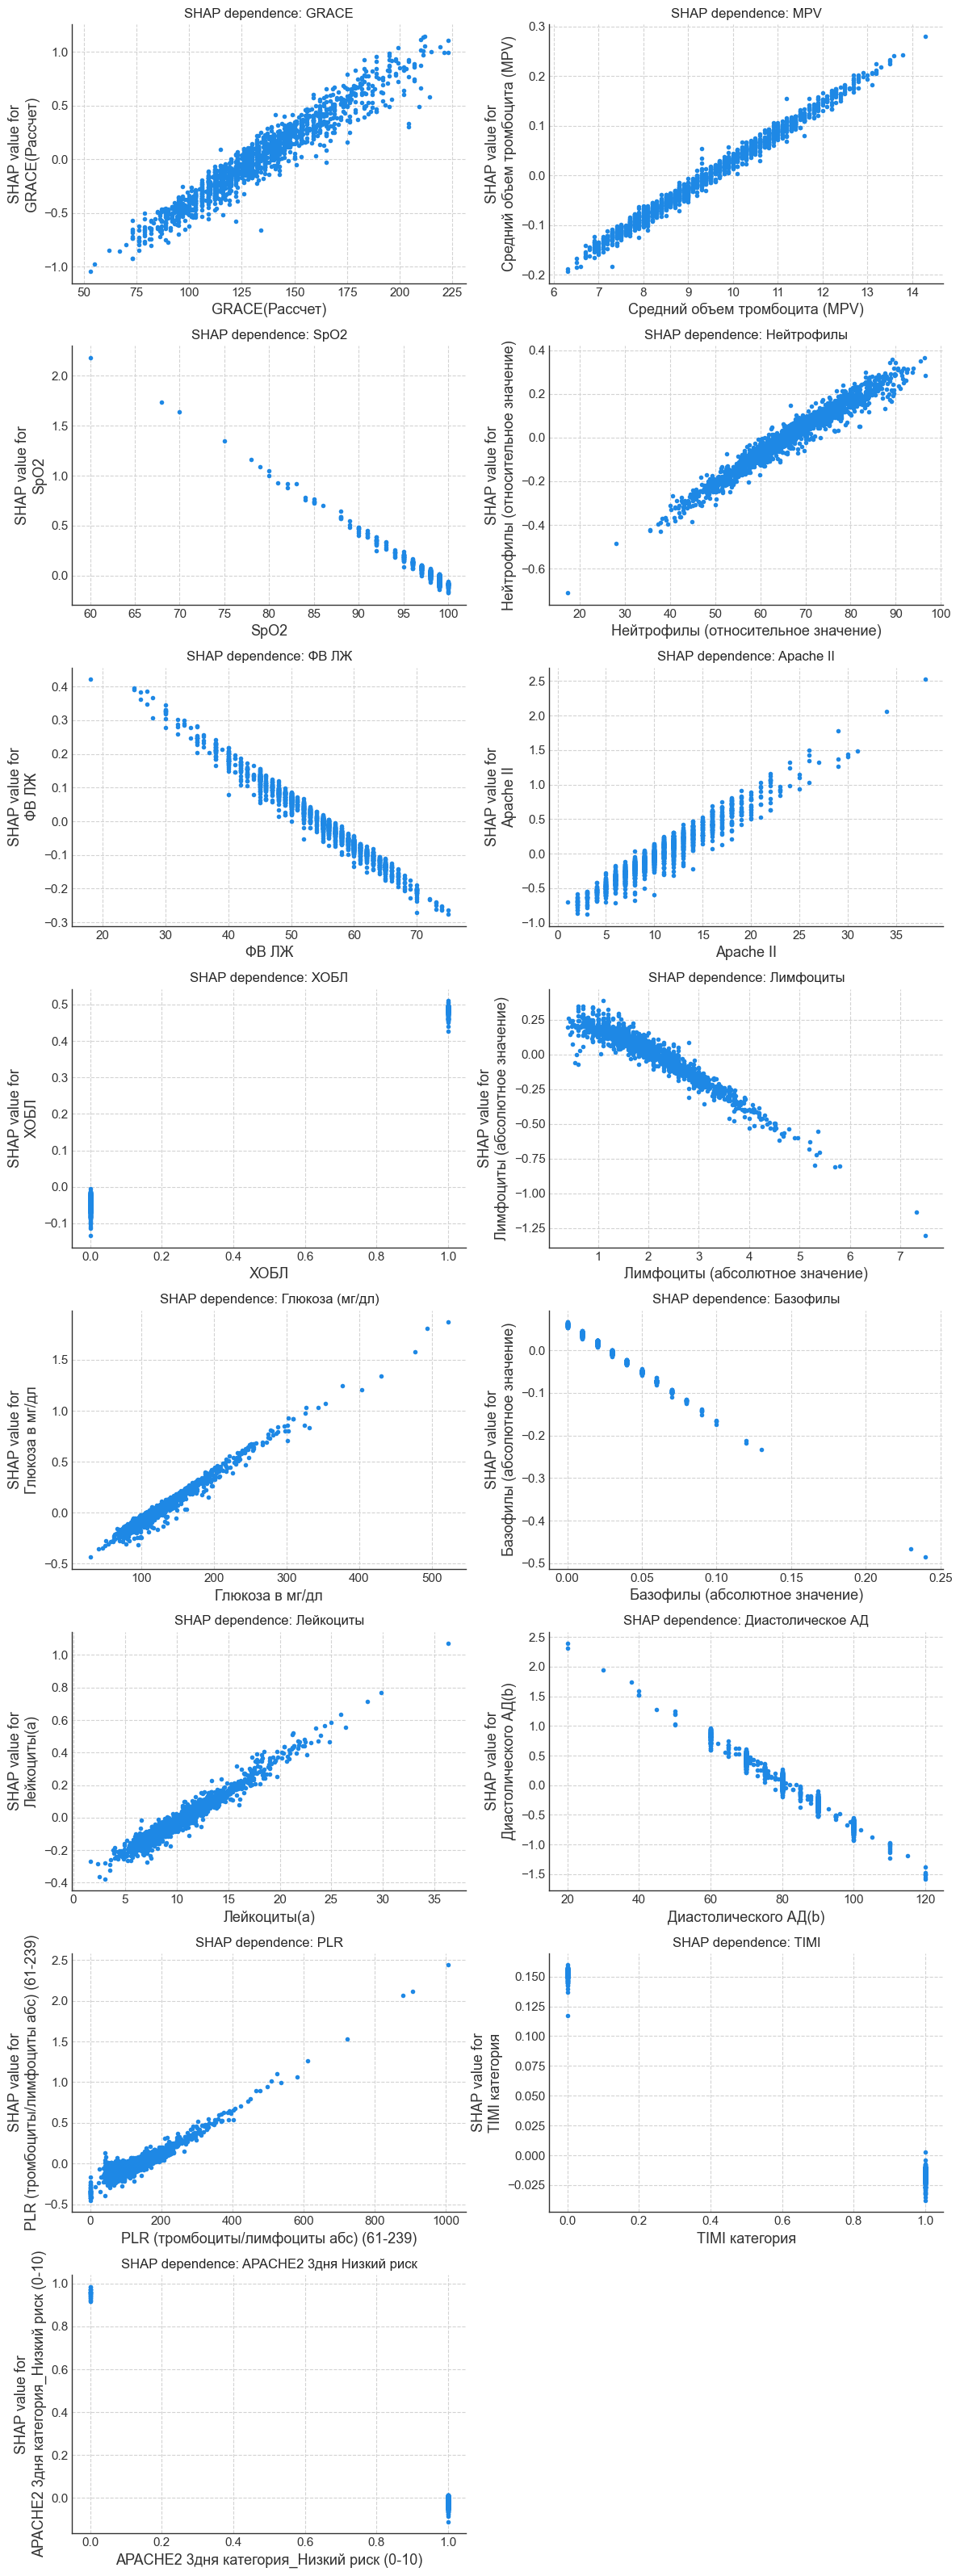


SHAP анализ завершен!


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, average_precision_score, recall_score, confusion_matrix, precision_score, f1_score, brier_score_loss
from scipy import stats
import shap

# ==================== ЗАГРУЗКА ДАННЫХ ====================
predict_df = pd.read_excel('датафрейм с предикторами 19_04_26 с Killip.xlsx')

# ==================== ФУНКЦИИ ДЛЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ ====================
def compute_confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    interval = sem * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean, mean - interval, mean + interval

def format_confidence_interval(mean, lower, upper):
    return f"{mean:.4f} [{lower:.4f}; {upper:.4f}]"

# ==================== ПРИЗНАКИ ====================
features = [
    'GRACE(Рассчет)',
    'Средний объем тромбоцита (MPV)',
    'SpO2',
    'Нейтрофилы (относительное значение)',
    'ФВ ЛЖ',
    'Apache II',
    'ХОБЛ',
    'Лимфоциты (абсолютное значение)',
    'Глюкоза в мг/дл',
    'Базофилы (абсолютное значение)',
    'Лейкоциты(a)',
    'Диастолического АД(b)',
    'PLR (тромбоциты/лимфоциты абс) (61-239)',
    'TIMI категория',
    'APACHE2 3дня категория_Низкий риск (0-10)'
]

# Очистка данных
predict_df_clean = predict_df.dropna(subset=features)

# Подготовка данных
X = predict_df_clean[features]
y = predict_df_clean['КШ развился в реанимации']

# ==================== ОБУЧЕНИЕ МОДЕЛИ ====================
results_data = []
n_repeats = 100
n_splits = 5
all_roc_auc_cv = []
all_roc_auc_test = []
all_pr_auc_test = []
all_sensitivity_test = []
all_specificity_test = []
all_f1_test = []
all_ppv_test = []
all_npv_test = []
all_brier_test = []

models = []

for i in range(n_repeats):
    np.random.seed(i + 42)
    # Разделение на обучающую и тестовую выборки (80/20)
    x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=i + 42)

    model = LogisticRegression(C= 0.1, max_iter= 1000, penalty = 'l2', solver = 'liblinear')

    # Кросс-валидация на 80% выборке
    cv_results = cross_validate(model, x_train, y_train, cv=StratifiedKFold(n_splits=n_splits),
                                scoring='roc_auc', return_estimator=True)
    all_roc_auc_cv.extend(cv_results['test_score'])

    # Обучение модели на всей обучающей выборке
    model.fit(x_train, y_train)

    # Получаем вероятности для тренировочной выборки, чтобы найти порог
    y_train_prob = model.predict_proba(x_train)[:, 1]
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
    optimal_idx = np.argmax(tpr_train - fpr_train)
    best_threshold = thresholds_train[optimal_idx]

    # Получаем вероятности для тестовой выборки
    y_test_prob = model.predict_proba(x_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    # Метрики
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    all_roc_auc_test.append(auc(fpr, tpr))
    all_pr_auc_test.append(average_precision_score(y_test, y_test_prob))
    all_sensitivity_test.append(recall_score(y_test, y_test_pred))

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    all_specificity_test.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    all_npv_test.append(tn / (tn + fn) if (tn + fn) > 0 else 0)
    all_ppv_test.append(precision_score(y_test, y_test_pred, zero_division=0))
    all_f1_test.append(f1_score(y_test, y_test_pred, zero_division=0))
    all_brier_test.append(brier_score_loss(y_test, y_test_prob))

    models.append(model)

# Находим лучшую модель
best_idx = all_roc_auc_test.index(max(all_roc_auc_test))
best_model = models[best_idx]

print(f"Лучшая модель — итерация {best_idx + 1} с ROC-AUC на тесте = {all_roc_auc_test[best_idx]:.4f}")
print("Коэффициенты лучшей модели:", best_model.coef_)
print("Смещение (intercept):", best_model.intercept_)

# ==================== ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ====================
roc_auc_cv_mean, roc_auc_cv_lower, roc_auc_cv_upper = compute_confidence_interval(all_roc_auc_cv)
roc_auc_test_mean, roc_auc_test_lower, roc_auc_test_upper = compute_confidence_interval(all_roc_auc_test)
pr_auc_test_mean, pr_auc_test_lower, pr_auc_test_upper = compute_confidence_interval(all_pr_auc_test)
sensitivity_test_mean, sensitivity_test_lower, sensitivity_test_upper = compute_confidence_interval(all_sensitivity_test)
specificity_test_mean, specificity_test_lower, specificity_test_upper = compute_confidence_interval(all_specificity_test)
f1_test_mean, f1_test_lower, f1_test_upper = compute_confidence_interval(all_f1_test)
ppv_test_mean, ppv_test_lower, ppv_test_upper = compute_confidence_interval(all_ppv_test)
npv_test_mean, npv_test_lower, npv_test_upper = compute_confidence_interval(all_npv_test)
brier_test_mean, brier_test_lower, brier_test_upper = compute_confidence_interval(all_brier_test)

results_data.append({
    'Кросс-валидационный ROC-AUC [95% ДИ]': format_confidence_interval(roc_auc_cv_mean, roc_auc_cv_lower, roc_auc_cv_upper),
    'Тестовый ROC-AUC [95% ДИ]': format_confidence_interval(roc_auc_test_mean, roc_auc_test_lower, roc_auc_test_upper),
    'Тестовый RAUC [95% ДИ]': format_confidence_interval(pr_auc_test_mean, pr_auc_test_lower, pr_auc_test_upper),
    'Тестовый Sensitivity [95% ДИ]': format_confidence_interval(sensitivity_test_mean, sensitivity_test_lower, sensitivity_test_upper),
    'Тестовый Specificity [95% ДИ]': format_confidence_interval(specificity_test_mean, specificity_test_lower, specificity_test_upper),
    'Тестовый F1-score [95% ДИ]': format_confidence_interval(f1_test_mean, f1_test_lower, f1_test_upper),
    'Тестовый PPV [95% ДИ]': format_confidence_interval(ppv_test_mean, ppv_test_lower, ppv_test_upper),
    'Тестовый NPV [95% ДИ]': format_confidence_interval(npv_test_mean, npv_test_lower, npv_test_upper),
    'Тестовый Brier Score [95% ДИ]': format_confidence_interval(brier_test_mean, brier_test_lower, brier_test_upper),
})

results_df = pd.DataFrame(results_data)
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛИ:")
print("="*80)
print(results_df.to_string(index=False))

# ==================== ПОЛУЧАЕМ ДАННЫЕ ДЛЯ ЛУЧШЕЙ МОДЕЛИ ====================
np.random.seed(best_idx + 42)
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=best_idx + 42
)

# ==================== SHAP АНАЛИЗ ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ ====================
print("\n" + "="*80)
print("SHAP АНАЛИЗ:")
print("="*80)

# Создаем explainer для линейной модели
# Используем LinearExplainer для логистической регрессии
explainer = shap.LinearExplainer(best_model, X_train_best, feature_perturbation='correlation_dependent')

# Рассчитываем SHAP значения
shap_values = explainer.shap_values(X_train_best)

# Для бинарной классификации shap_values может быть списком из двух массивов
# Нам нужны значения для класса 1 (положительный исход)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Создаем DataFrame с SHAP значениями
shap_values_df = pd.DataFrame(shap_values, columns=features)

# Настройка графиков
plt.rcParams.update({'font.size': 10})
k = 3
features_ru = {'GRACE(Рассчет)': 'GRACE',
    'Средний объем тромбоцита (MPV)': 'MPV',
    'SpO2': 'SpO2',
    'Нейтрофилы (относительное значение)': 'Нейтрофилы' ,
    'ФВ ЛЖ': 'ФВ ЛЖ',
    'Apache II': 'Apache II',
    'ХОБЛ': 'ХОБЛ',
    'Лимфоциты (абсолютное значение)': 'Лимфоциты',
    'Глюкоза в мг/дл': 'Глюкоза (мг/дл)',
    'Базофилы (абсолютное значение)': 'Базофилы',
    'Лейкоциты(a)' : 'Лейкоциты',
    'Диастолического АД(b)': 'Диастолическое АД',
    'PLR (тромбоциты/лимфоциты абс) (61-239)' : 'PLR',
    'TIMI категория': 'TIMI',
    'APACHE2 3дня категория_Низкий риск (0-10)': 'APACHE2 3дня Низкий риск'}

# Создаем графики для всех признаков
n_features = len(features)
n_rows = (n_features + 1) // 2

plt.figure(figsize=[12, 4 * n_rows], dpi=100)

for idx, feature in enumerate(features):
    plt.subplot(n_rows, 2, idx + 1)

    # Создаем DataFrame для текущего признака
    pp = pd.DataFrame({
        'X': np.array(X_train_best[feature]),
        'shap': np.array(shap_values[:, idx])
    })

    # Находим пороговое значение SHAP
    m = np.max(pp['shap'])
    # Значение предиктора, с которого SHAP превышает max(shap)/k
    mask = pp['shap'] > m/k
    if mask.any():
        xx = pp.loc[mask, 'X'].min()
    else:
        xx = np.nan
    yy = np.min(pp['shap'])

    port_text = f"{xx:.2f}" if not np.isnan(xx) else "не найден"
    print(f"{feature}: порог={port_text}, min_shap={yy:.4f}, max_shap={m:.4f}")

    plt.minorticks_on()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.scatter(X_train_best[feature], shap_values[:, idx], s=10, alpha=0.6, c='steelblue')

    # Настройка границ осей
    x_min = np.min(X_train_best[feature])
    x_max = np.max(X_train_best[feature])
    x_range = x_max - x_min
    plt.xlim(x_min - x_range/20, x_max + x_range/20)

    # Подписи
    feature_name_ru = features_ru.get(feature, feature)
    plt.xlabel(feature_name_ru)
    plt.ylabel('SHAP value')

    # Добавляем линии
    plt.axhline(y=0, color='black', linewidth=1)
    plt.axhline(y=m/k, color='gray', linestyle='--', alpha=0.7)

    if not np.isnan(xx):
        plt.axvline(x=xx, color='red', linestyle='--', alpha=0.7)
        plt.text(xx + x_range/30, yy, f'{xx:.1f}',
                 color='red', ha='center', va='bottom', fontsize=9)

plt.suptitle('SHAP зависимость: значение признака vs вклад в предсказание', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==================== ДОПОЛНИТЕЛЬНЫЕ SHAP ВИЗУАЛИЗАЦИИ ====================
feature_names_ru = [features_ru[feature] for feature in features]
# 1. Summary plot (главный график важности признаков)
print("\nСоздание summary plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, show=False)
plt.title('SHAP summary plot - влияние признаков на модель', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Bar plot (средние абсолютные SHAP значения)
print("\nСоздание bar plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_best, feature_names=feature_names_ru, plot_type="bar", show=False)
plt.title('Важность признаков по SHAP (среднее абсолютное значение)', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Waterfall plot для конкретного наблюдения (например, первого пациента)
print("\nСоздание waterfall plot для первого пациента...")
# Получаем expected value
if isinstance(explainer.expected_value, list):
    expected_value = explainer.expected_value[1]
else:
    expected_value = explainer.expected_value

# Создаем Explanation object
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=expected_value,
    data=X_train_best.iloc[0].values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False, max_display=len(features))
plt.title(f'Waterfall plot для пациента 1 (предсказание: {best_model.predict_proba(X_train_best.iloc[0:1])[0,1]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Сохраняем SHAP значения для дальнейшего анализа
shap_df = pd.DataFrame(shap_values, columns=[f'SHAP_{f}' for f in features])
shap_df.to_excel('shap_values.xlsx', index=False)
print("\nSHAP значения сохранены в 'shap_values.xlsx'")

# 5. Дополнительно: график зависимости SHAP от значения признака (альтернативный вариант)
print("\nСоздание дополнительных графиков зависимости...")
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    shap.dependence_plot(
        feature, shap_values, X_train_best,
        feature_names=features, ax=ax, show=False,
        interaction_index=None
    )
    ax.set_title(f'SHAP dependence: {features_ru.get(feature, feature)}')

# Скрываем лишние подграфики
for idx in range(len(features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SHAP анализ завершен!")
print("="*80)